# Implementing a single layer ML network

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

## Create the dataset

In this part you do not need to do anything. Ask yourself, what the possible values for x1,x2, and y_gt are. You always need to do this in order to use the right non-linearity functions

In [2]:
# Create two vectors containing random data
x1    = np.random.random(500)*2-1
x2    = np.random.random(500)*2-1

In [3]:
# Create the labels of the dataset with some noise
noise = 0.2*np.random.randn(500)
y_gt  = ((x1+x2+noise)>0)*2-1 # gt .. ground truth

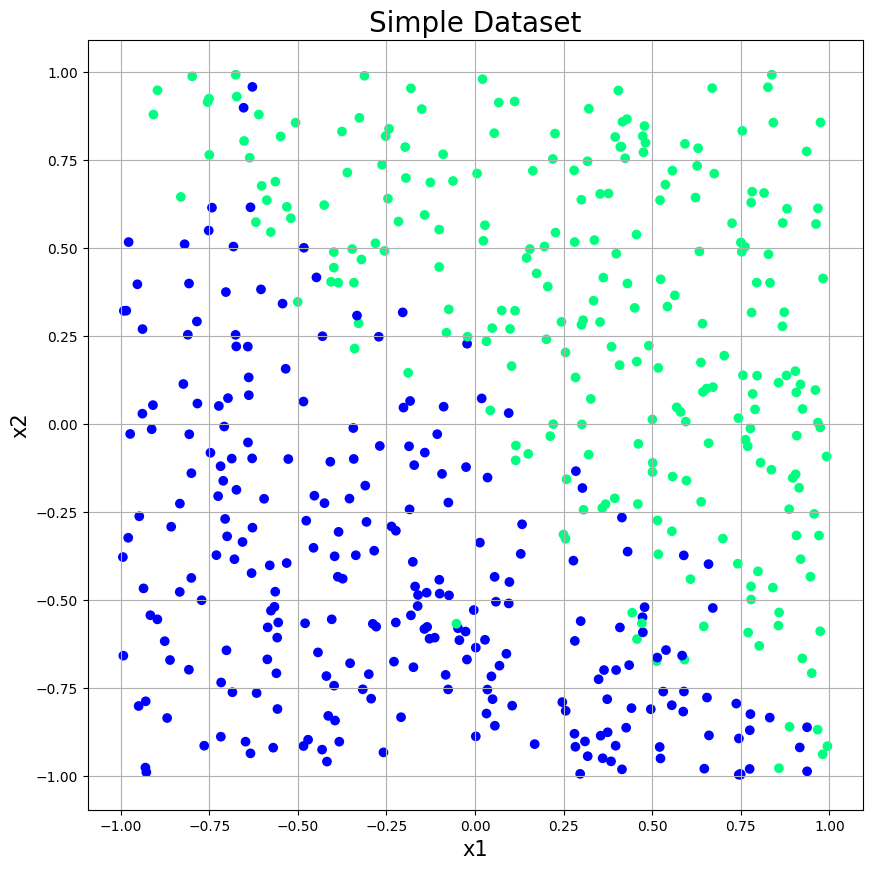

In [4]:
# Plot the raw data
plt.figure(figsize=(10,10))
plt.scatter(x1,x2,c=y_gt,cmap='winter')
plt.grid(True)
plt.xlabel('x1',fontsize=15)
plt.ylabel('x2',fontsize=15)
plt.title('Simple Dataset',fontsize=20)
plt.show()

## Creating the network

In [5]:
def f(x):
    # Input:  x     [R^n] (vec)
    # Output: f(x)  [R^n]
    return np.tanh(x) # TODO: Use an appropriate non-linearity (e.g. tanh,sigmoid,relu). Use the functions from the numpy library

def df(x):
    # Input:  x         [R^n]
    # Output: df(x)/dx  [R^n]
    return 1 - np.tanh(x)**2 # TODO: Calculate the derivative of your non-linearity function

In [6]:
def pred(x1,x2,w1,w2):
    # Input:  x1                [R^n] The first dimension of the data points
    #         x2                [R^n] The second dimension of the data points
    #         w1                [R]   (Scalar) Scaling factor of x1
    #         w2                [R]   Scaling factor of x2
    #          
    # Output: f(x1*w1 + x2*w2)  [R^n] This is the predicted y values for the points defined by x1 and x2
    
    return f(x1*w1 + x2*w2) # TODO: Return f(x1*w1 + x2*w2)

In [7]:
def loss_function(x1,x2,w1,w2,y_gt):
    # Input:  x1                [R^n] The first dimension of the data points
    #         x2                [R^n] The second dimension of the data points
    #         w1                [R]   (Scalar) Scaling factor of x1
    #         w2                [R]   Scaling factor of x2
    #         y_gt              [R^n] The correct labels for your data (ground truth)
    #          
    # Output: loss(x1,x2)       [R^n] This is the square loss for each point: (f(x1*w1+x2*w2)-y_gt)^2
    
    return (f(x1*w1+x2*w2)-y_gt)**2 # TODO: Return square loss

In [8]:
def calculate_derivatives(x1,x2,w1,w2,y_gt):
    # Input:  x1                [R^n] The first dimension of the data points
    #         x2                [R^n] The second dimension of the data points
    #         w1                [R]   (Scalar) Scaling factor of x1
    #         w2                [R]   Scaling factor of x2
    #         y_gt              [R^n] The correct labels for your data (ground truth)
    #          
    # Output: dw1,dw2           [R],[R]      
    # This function returns two Scalars. Element 1: d(loss)/d(w1). Element 2: d(loss)/d(w2)
    first = 2*(pred(x1,x2,w1,w2) - y_gt)*df(x1*w1+x2*w2)*x1
    second = 2*(pred(x1,x2,w1,w2) - y_gt)*df(x1*w1+x2*w2)*x2
    return (first, second)  # TODO: Calculate the derivatives of w1 and w2 with tespect to the loss function

## Train the network

In [9]:
w1  = random.random()*20-10 # Initial value of w1
w2  = random.random()*20-10 # Initial value of w2

eta = 0.1                   # Eta is used to calculate by how much w1 and w2 are adapted each epoch

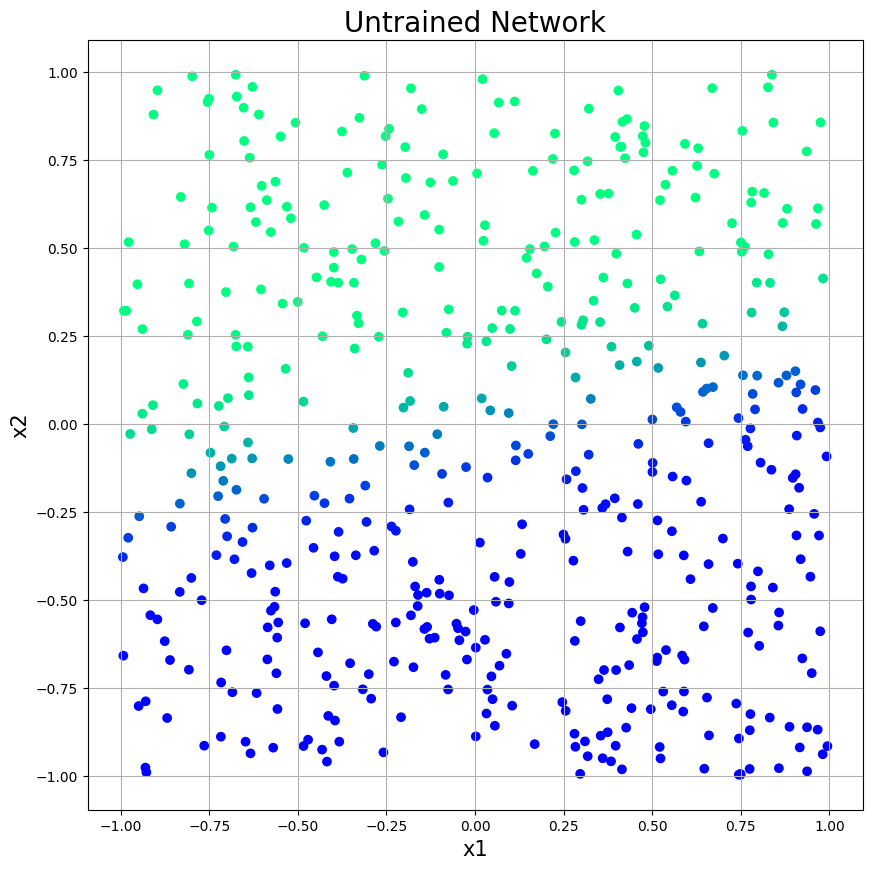

In [10]:
# Make a prediction by the untrained network and plot it
y_pred = pred(x1,x2,w1,w2)

# Plot the raw data
plt.figure(figsize=(10,10))
plt.scatter(x1,x2,c=y_pred,cmap='winter')
plt.grid(True)
plt.xlabel('x1',fontsize=15)
plt.ylabel('x2',fontsize=15)
plt.title('Untrained Network',fontsize=20)
plt.show()

In [11]:
for i in range(100000): # I increased the loop size by 10x :)
    losses = loss_function(x1,x2,w1,w2,y_gt)
    if i%500 == 0: # print solutions to every 500th step
        print('Epoch: ' + str(i).ljust(10) + ' Combined loss: ' + str(np.mean(losses)))
    
    dw1, dw2 = calculate_derivatives(x1,x2,w1,w2,y_gt)  # TODO: Calculate by how much to change w1 and w2 (using calculate_derivatives(...))
    w1 = w1 - eta*dw1
    w2 = w2 - eta*dw2# TODO: Update w1 and w2. Do not forget eta (i.e. step size)

Epoch: 0          Combined loss: 0.9576352860212908
Epoch: 500        Combined loss: 0.1639982070360564
Epoch: 1000       Combined loss: 0.09906403770249772
Epoch: 1500       Combined loss: 0.07402733000125929
Epoch: 2000       Combined loss: 0.06563466532116759
Epoch: 2500       Combined loss: 0.057297171262439876
Epoch: 3000       Combined loss: 0.05706299595862905
Epoch: 3500       Combined loss: 0.05690011607644046
Epoch: 4000       Combined loss: 0.0567798026308432
Epoch: 4500       Combined loss: 0.056687308338631795
Epoch: 5000       Combined loss: 0.056613980741336244
Epoch: 5500       Combined loss: 0.05655438486220099
Epoch: 6000       Combined loss: 0.05650491666714168
Epoch: 6500       Combined loss: 0.056463056138375864
Epoch: 7000       Combined loss: 0.056426899883874296
Epoch: 7500       Combined loss: 0.056394693580126304
Epoch: 8000       Combined loss: 0.05636306631969823
Epoch: 8500       Combined loss: 0.048361490751432694
Epoch: 9000       Combined loss: 0.0483137

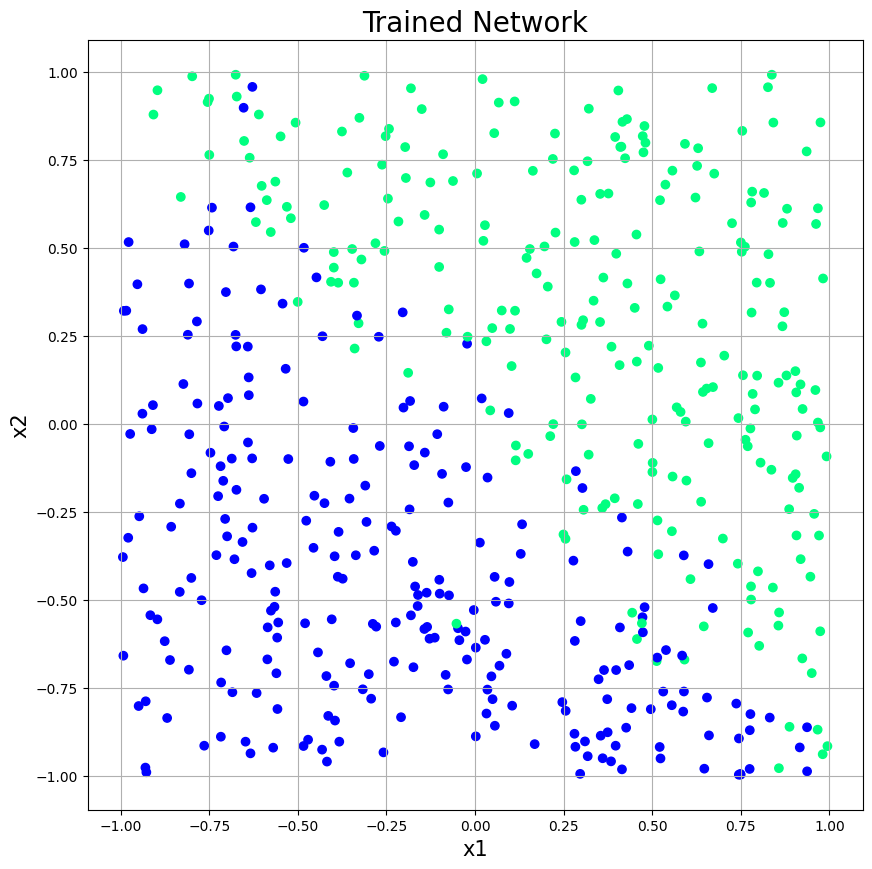

In [12]:
# Make a prediction by the trained network and plot it
y_pred = pred(x1,x2,w1,w2)

# Plot the raw data
plt.figure(figsize=(10,10))
plt.scatter(x1,x2,c=y_pred,cmap='winter')
plt.grid(True)
plt.xlabel('x1',fontsize=15)
plt.ylabel('x2',fontsize=15)
plt.title('Trained Network',fontsize=20)
plt.show()